In [1]:
import os, glob, math, random, cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.utils import Sequence, to_categorical
from sklearn.model_selection import train_test_split

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-03-31 13:23:24.121490: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774963404.354140      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774963404.421479      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774963404.951258      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774963404.951295      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774963404.951298      55 computation_placer.cc:177] computation placer alr

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [10]:
IMG_SIZE        = (224, 224)
FRAMES_PER_CLIP = 40
BATCH_SIZE      = 4
CLASSES         = ["RoadAccidents", "Robbery", "normal"]

TRIAL4_WEIGHTS  = "/kaggle/input/models/bubblu123/lrcn-50/tensorflow2/default/1/best_target.keras"  
OUT_MODEL       = "/kaggle/working/trial5_best.keras"

LEARNING_RATE   = 1e-5        
UNFREEZE_LAYERS = 40          
EPOCHS          = 30        

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [11]:
BASE_PATH = "/kaggle/input/datasets/bubblu123/intruder-class3/Intruder_classification/intruder_project"

rows = []
for cls in ["RoadAccidents", "Robbery"]:
    folder = os.path.join(BASE_PATH, "anomaly", cls)
    for p in glob.glob(os.path.join(folder, "*")):
        if p.lower().endswith((".mp4", ".avi", ".mov")):
            rows.append({"path": p, "label": cls})

for p in glob.glob(os.path.join(BASE_PATH, "normal", "*")):
    if p.lower().endswith((".mp4", ".avi", ".mov")):
        rows.append({"path": p, "label": "normal"})

df = pd.DataFrame(rows)
print("Total:", len(df))
print(df["label"].value_counts())

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=SEED
)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Total: 450
label
RoadAccidents    150
Robbery          150
normal           150
Name: count, dtype: int64
Train: 360 | Val: 90


In [12]:
def load_clip_with_heavy_aug(path, frames=40, size=(224, 224), augment=False):
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if augment and total_frames > frames + 5:
        start_frame = random.randint(0, total_frames - frames - 1)
        idxs = np.linspace(start_frame, start_frame + frames - 1, frames).astype(int)
    else:
        idxs = np.linspace(0, max(0, total_frames - 1), frames).astype(int)

    frames_out = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size)

        if augment:
            if random.random() > 0.5:
                frame = cv2.flip(frame, 1)
            if random.random() > 0.5:
                frame = cv2.convertScaleAbs(frame, alpha=random.uniform(0.7, 1.3))

        frames_out.append(frame.astype("float32") / 255.0)

    cap.release()

    while len(frames_out) < frames:
        frames_out.append(np.zeros((size[0], size[1], 3)))

    return np.stack(frames_out, axis=0)

class FinalVideoSequence(Sequence):
    def __init__(self, df, batch_size=4, augment=False):
        self.df         = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.augment    = augment
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def on_epoch_end(self):
        if self.augment:
            self.df = self.df.sample(frac=1.0).reset_index(drop=True)

    def __getitem__(self, idx):
        batch = self.df.iloc[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []
        for _, row in batch.iterrows():
            X.append(load_clip_with_heavy_aug(row["path"], augment=self.augment))
            y.append(CLASSES.index(row["label"]))
        return np.array(X), to_categorical(np.array(y), num_classes=3)


train_gen = FinalVideoSequence(train_df, batch_size=BATCH_SIZE, augment=True)
val_gen   = FinalVideoSequence(val_df,   batch_size=BATCH_SIZE, augment=False)

xb, yb = train_gen[0]
print(f"Batch shape: {xb.shape} | Label shape: {yb.shape}")

Batch shape: (4, 40, 224, 224, 3) | Label shape: (4, 3)


In [13]:
print(f"Loading: {TRIAL4_WEIGHTS}")
model = tf.keras.models.load_model(TRIAL4_WEIGHTS, compile=False)
print("Loaded successfully.")

backbone = model.layers[1].layer
backbone.trainable = True
for layer in backbone.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

trainable_layers = sum(1 for l in backbone.layers if l.trainable)
print(f"Backbone trainable layers: {trainable_layers} / {len(backbone.layers)}")

loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(
    gamma=2.0, alpha=0.25, label_smoothing=0.1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=loss_fn,
    metrics=["accuracy"]
)
print(f"Compiled. LR={LEARNING_RATE} | Unfrozen={UNFREEZE_LAYERS} layers")

Loading: /kaggle/input/models/bubblu123/lrcn-50/tensorflow2/default/1/best_target.keras
Loaded successfully.
Backbone trainable layers: 25 / 154
Compiled. LR=1e-05 | Unfrozen=40 layers


In [14]:
ckpt = tf.keras.callbacks.ModelCheckpoint(
    OUT_MODEL,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

rlr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,       
    min_lr=1e-7,
    verbose=1
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [15]:
print("Starting Trial 5...")
print(f"  Checkpoint : {TRIAL4_WEIGHTS}")
print(f"  LR         : {LEARNING_RATE}  (Trial 4 was 2e-5)")
print(f"  Unfrozen   : {UNFREEZE_LAYERS} layers  (Trial 4 was 50)")
print(f"  Epochs     : {EPOCHS}")

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[ckpt, rlr, es]
)

best_epoch = int(np.argmax(history.history["val_accuracy"]))
best_acc   = history.history["val_accuracy"][best_epoch]
print(f"\nBest val_accuracy: {best_acc*100:.2f}% at epoch {best_epoch+1}")
print(f"Model saved to   : {OUT_MODEL}")

Starting Trial 5...
  Checkpoint : /kaggle/input/models/bubblu123/lrcn-50/tensorflow2/default/1/best_target.keras
  LR         : 1e-05  (Trial 4 was 2e-5)
  Unfrozen   : 40 layers  (Trial 4 was 50)
  Epochs     : 30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5274 - loss: 0.1035
Epoch 1: val_accuracy improved from -inf to 0.77778, saving model to /kaggle/working/trial5_best.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 851s 7s/step - accuracy: 0.5277 - loss: 0.1035 - val_accuracy: 0.7778 - val_loss: 0.0830 - learning_rate: 1.0000e-05
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5816 - loss: 0.1052
Epoch 2: val_accuracy did not improve from 0.77778
90/90 ━━━━━━━━━━━━━━━━━━━━ 587s 7s/step - accuracy: 0.5814 - loss: 0.1052 - val_accuracy: 0.7556 - val_loss: 0.0827 - learning_rate: 1.0000e-05
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5996 - loss: 0.1034
Epoch 3: val_accuracy did not improve from 0.77778
90/90 ━━━━━━━━━━━━━━━━━━━━ 591s 7s/step - accuracy: 0.5992 - loss: 0.1034 - val_accuracy: 0.7667 - val_loss: 0.0825 - learning_rate: 1.0000e-05
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5333 - loss: 0.1090
Epoch 4: val_accuracy improved 

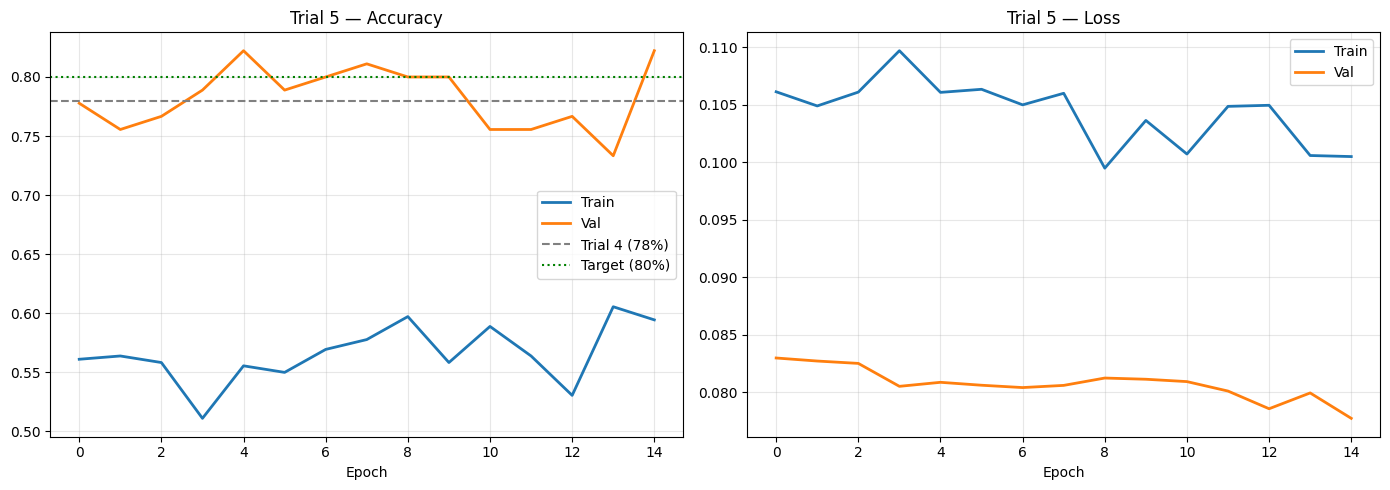

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val",   linewidth=2)
axes[0].axhline(0.78, color="gray",  linestyle="--", label="Trial 4 (78%)")
axes[0].axhline(0.80, color="green", linestyle=":",  label="Target (80%)")
axes[0].set_title("Trial 5 — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train", linewidth=2)
axes[1].plot(history.history["val_loss"], label="Val",   linewidth=2)
axes[1].set_title("Trial 5 — Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/trial5_curves.png", dpi=150)
plt.show()

Loading model from: /kaggle/working/trial5_best.keras
Running inference on validation set...

  CLASSIFICATION REPORT
               precision    recall  f1-score   support

RoadAccidents       0.79      0.87      0.83        30
      Robbery       0.89      0.83      0.86        30
       normal       0.79      0.77      0.78        30

     accuracy                           0.82        90
    macro avg       0.82      0.82      0.82        90
 weighted avg       0.82      0.82      0.82        90



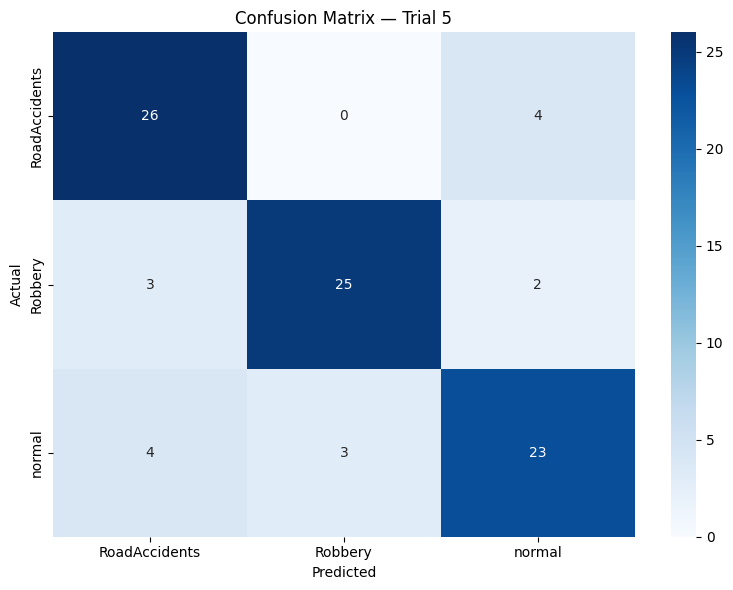

Overall accuracy : 82.22%
Trial 4 baseline : 78.00%
Delta            : +4.22%


In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_and_plot(model_path, val_gen, classes=["RoadAccidents", "Robbery", "normal"]):
    print(f"Loading model from: {model_path}")
    model = tf.keras.models.load_model(model_path, compile=False)

    y_true, y_pred = [], []
    print("Running inference on validation set...")
    for i in range(len(val_gen)):
        x_batch, y_batch = val_gen[i]
        preds = model.predict(x_batch, verbose=0)
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred.extend(np.argmax(preds,   axis=1))

    print("\n" + "="*30)
    print("  CLASSIFICATION REPORT")
    print("="*30)
    print(classification_report(y_true, y_pred, target_names=classes))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix — Trial 5")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig("/kaggle/working/trial5_confusion.png", dpi=150)
    plt.show()

    overall = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
    print(f"Overall accuracy : {overall*100:.2f}%")
    print(f"Trial 4 baseline : 78.00%")
    print(f"Delta            : {(overall - 0.78)*100:+.2f}%")


evaluate_and_plot(OUT_MODEL, val_gen)